# A2 Scoring + EDA

## Target
Implement the **visibility score** and run the **EDA plan**.
The goal is to validate that the score behaves physically and seasonally as expected, and to compare locations.

## What is done in this notebook
- Load hourly data for multiple locations (night flag, cloud, moon, Kp).
- Compute **hourly visibility factors** (darkness, cloud, moon, Kp) and the combined score.
- Aggregate to **night-level** summaries.
- Build **climatology views**:
  - monthly averages across all years
  - week-of-year score climatology
- Plot the expected seasonal patterns and compare locations.

This notebook is the baseline scoring + EDA pass before focusing on specific sites
(see the Yellowknife and Fort Smith versions for location-specific deep dives).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_DIR = Path("Data/processed")


In [2]:
kiruna = pd.read_csv(DATA_DIR / "kiruna_moon_night.csv", parse_dates=["timestamp_utc"])
yellowknife = pd.read_csv(DATA_DIR / "yellowknife_moon_night.csv", parse_dates=["timestamp_utc"])
reykjavik = pd.read_csv(DATA_DIR / "reykjavik_moon_night.csv", parse_dates=["timestamp_utc"])
fortsmith = pd.read_csv(DATA_DIR / "fortsmith_moon_night.csv", parse_dates=["timestamp_utc"])

kiruna.head()


,timestamp_utc,location,is_night,cloud_cover,wind_speed_10m (km/h),kp,moon_altitude_deg,moon_illumination,D,F_cloud,F_moon,F_kp,visibility_score
0,1998-01-01 00:00:00+00:00,kiruna,True,100,7.7,0.667,-37.568359,0.065674,1.0,0.0,1.0,0.0,0.0
1,1998-01-01 01:00:00+00:00,kiruna,True,100,8.0,0.667,-37.881301,0.068026,1.0,0.0,1.0,0.0,0.0
2,1998-01-01 02:00:00+00:00,kiruna,True,100,9.5,0.667,-36.570516,0.070419,1.0,0.0,1.0,0.0,0.0
3,1998-01-01 03:00:00+00:00,kiruna,True,100,10.1,1.333,-33.781938,0.072852,1.0,0.0,1.0,0.0,0.0
4,1998-01-01 04:00:00+00:00,kiruna,True,100,10.8,1.333,-29.801000,0.075325,1.0,0.0,1.0,0.0,0.0


## 0) Time aggregation convention
Group by (location, night_date_local) as the EDA atomic unit, then aggregate by month (climatology).

In [3]:
def add_night_date(df, tz):
    df = df.copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert(tz)
    df["night_date_local"] = df["timestamp_local"].dt.date
    return df

def nightly_aggregate(df, location_name):
    night = df[df["is_night"]].copy()
    g = night.groupby("night_date_local")
    out = pd.DataFrame({
        "night_duration_hours": g["is_night"].size(),
        "cloud_night_mean": g["cloud_cover"].mean(),
        "cloud_night_p90": g["cloud_cover"].quantile(0.90),
        "kp_night_max": g["kp"].max(),
        "kp_night_mean": g["kp"].mean(),
        "moon_alt_night_max": g["moon_altitude_deg"].max(),
        "moon_alt_night_mean": g["moon_altitude_deg"].mean(),
        "S_night_mean": g["visibility_score"].mean(),
        "S_night_max": g["visibility_score"].max(),
    })
    out["location"] = location_name
    return out.reset_index()

kiruna = add_night_date(kiruna, "Europe/Stockholm")
yellowknife = add_night_date(yellowknife, "America/Yellowknife")
reykjavik = add_night_date(reykjavik, "Atlantic/Reykjavik")
fortsmith = add_night_date(fortsmith, "America/Edmonton")

kiruna_night = nightly_aggregate(kiruna, "kiruna")
yellowknife_night = nightly_aggregate(yellowknife, "yellowknife")
reykjavik_night = nightly_aggregate(reykjavik, "reykjavik")
fortsmith_night = nightly_aggregate(fortsmith, "fortsmith")

nightly_all = pd.concat([kiruna_night, yellowknife_night, reykjavik_night,fortsmith_night], ignore_index=True)
nightly_all["night_date_local"] = pd.to_datetime(nightly_all["night_date_local"])
nightly_all["month"] = nightly_all["night_date_local"].dt.month
nightly_all.head()


,night_date_local,night_duration_hours,cloud_night_mean,cloud_night_p90,kp_night_max,kp_night_mean,moon_alt_night_max,moon_alt_night_mean,S_night_mean,S_night_max,location,month
0,1998-01-01,12,100.000000,100.0,1.333,0.750000,-0.124217,-23.144142,0.0,0.0,kiruna,1
1,1998-01-02,13,99.846154,100.0,2.000,1.282000,6.532234,-19.248776,0.0,0.0,kiruna,1
2,1998-01-03,13,99.461538,100.0,2.000,0.564000,13.379963,-13.323955,0.0,0.0,kiruna,1
3,1998-01-04,13,99.076923,100.0,1.000,0.435923,19.708094,-6.860379,0.0,0.0,kiruna,1
4,1998-01-05,13,93.000000,97.0,1.667,0.615231,25.102508,-0.024833,0.0,0.0,kiruna,1


## Monthly climatology (average across all years)

In [4]:
monthly = nightly_all.groupby(["location", "month"]).agg(
    night_duration_mean=("night_duration_hours", "mean"),
    night_duration_std=("night_duration_hours", "std"),
    cloud_mean=("cloud_night_mean", "mean"),
    cloud_std=("cloud_night_mean", "std"),
    cloud_p90_mean=("cloud_night_p90", "mean"),
    kp_max_mean=("kp_night_max", "mean"),
    kp_mean_mean=("kp_night_mean", "mean"),
    moon_alt_max_mean=("moon_alt_night_max", "mean"),
    S_mean=("S_night_mean", "mean"),
    S_std=("S_night_mean", "std"),
    S_max_mean=("S_night_max", "mean")
).reset_index()
monthly.head()

weekly = nightly_all.copy()
weekly["week"] = weekly["night_date_local"].dt.isocalendar().week.astype(int)
weekly_agg = weekly.groupby(["location", "week"]).agg(
    night_duration_mean=("night_duration_hours", "mean"),
    night_duration_std=("night_duration_hours", "std"),
    cloud_mean=("cloud_night_mean", "mean"),
    cloud_std=("cloud_night_mean", "std"),
    cloud_p90_mean=("cloud_night_p90", "mean"),
    kp_max_mean=("kp_night_max", "mean"),
    kp_mean_mean=("kp_night_mean", "mean"),
    moon_alt_max_mean=("moon_alt_night_max", "mean"),
    S_mean=("S_night_mean", "mean"),
    S_std=("S_night_mean", "std"),
    S_max_mean=("S_night_max", "mean")
).reset_index()

# Fill missing weeks per location with 0 night duration to avoid gaps
all_weeks = range(1, 54)
locations = weekly_agg["location"].unique()
full_index = pd.MultiIndex.from_product([locations, all_weeks], names=["location", "week"])
weekly_full = weekly_agg.set_index(["location", "week"]).reindex(full_index).reset_index()
weekly_full["night_duration_mean"] = weekly_full["night_duration_mean"].fillna(0)
weekly_full["night_duration_std"] = weekly_full["night_duration_std"].fillna(0)
weekly_full["cloud_mean"] = weekly_full["cloud_mean"].fillna(0)
weekly_full["cloud_std"] = weekly_full["cloud_std"].fillna(0)
weekly_full["kp_max_mean"] = weekly_full["kp_max_mean"].fillna(0)
weekly_full["kp_mean_mean"] = weekly_full["kp_mean_mean"].fillna(0)
weekly_full["moon_alt_max_mean"] = weekly_full["moon_alt_max_mean"].fillna(0)
weekly_full["S_mean"] = weekly_full["S_mean"].fillna(0)
weekly_full["S_std"] = weekly_full["S_std"].fillna(0)
weekly_full["S_max_mean"] = weekly_full["S_max_mean"].fillna(0)


## 1) Nighttime duration (monthly climatology)

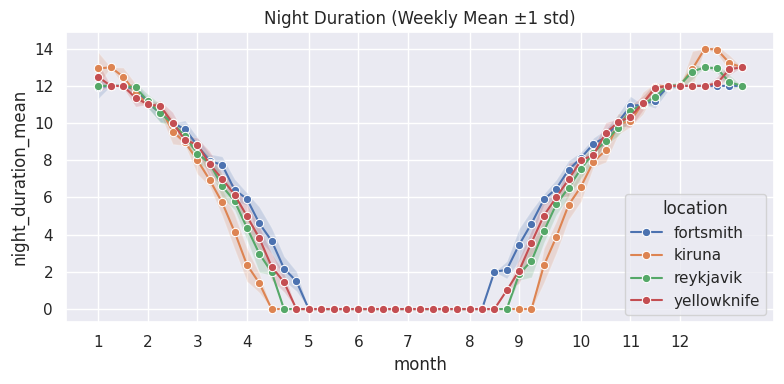

In [5]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="night_duration_mean", hue="location", marker="o")
for loc in weekly_full["location"].unique():
    sub = weekly_full[weekly_full["location"] == loc]
    plt.fill_between(sub["week"], sub["night_duration_mean"] - sub["night_duration_std"], sub["night_duration_mean"] + sub["night_duration_std"], alpha=0.2)
plt.title("Night Duration (Weekly Mean ±1 std)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.tight_layout()
plt.show()


## 2) Cloud coverage (night, monthly climatology)

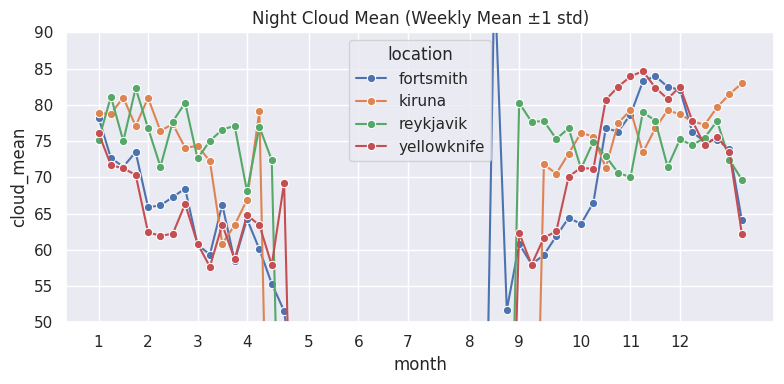

In [6]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="cloud_mean", hue="location", marker="o")
for loc in weekly_full["location"].unique():
    sub = weekly_full[weekly_full["location"] == loc]
    # plt.fill_between(sub["week"], sub["cloud_mean"] - sub["cloud_std"], sub["cloud_mean"] + sub["cloud_std"], alpha=0.2)
plt.title("Night Cloud Mean (Weekly Mean ±1 std)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.ylim((50,90))
plt.tight_layout()
plt.show()


## 3) Kp activity (night, monthly climatology)

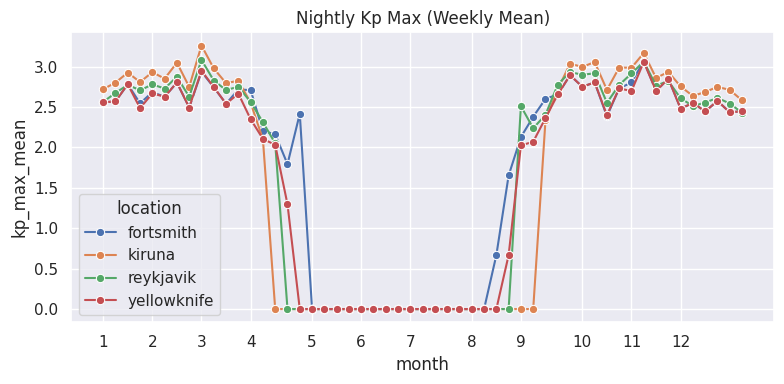

In [7]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="kp_max_mean", hue="location", marker="o")
plt.title("Nightly Kp Max (Weekly Mean)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.tight_layout()
plt.show()


## 4) Moon altitude (night, monthly climatology)

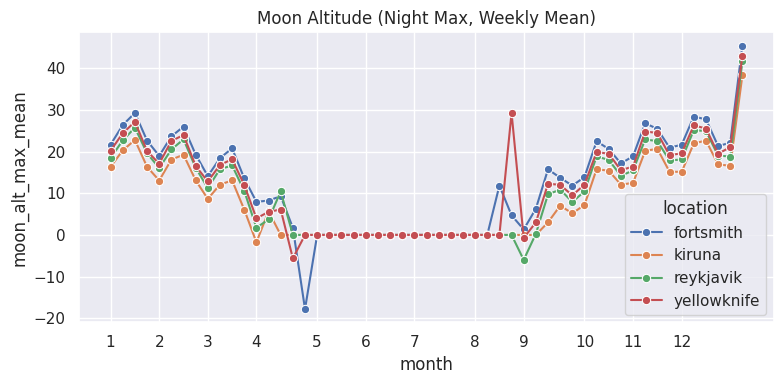

In [8]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="moon_alt_max_mean", hue="location", marker="o")
plt.title("Moon Altitude (Night Max, Weekly Mean)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.tight_layout()
plt.show()


## 5) Visibility score (monthly climatology)

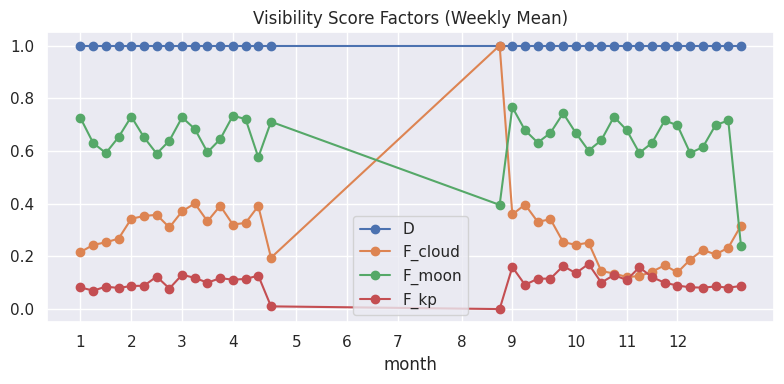

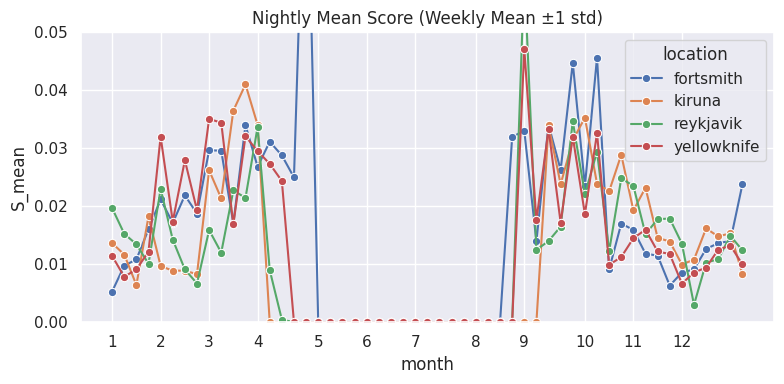

In [14]:
# Weekly mean of visibility-score factors (D, F_cloud, F_moon, F_kp)
factor_cols = ['D', 'F_cloud', 'F_moon', 'F_kp']
missing = [c for c in factor_cols if c not in yellowknife.columns]
if missing:
    raise KeyError(f'Missing columns in yellowknife: {missing}')

yellowknife['week'] = yellowknife['timestamp_utc'].dt.isocalendar().week.astype(int)
weekly_factors = (
    yellowknife[yellowknife['is_night'] == True]
    .groupby('week')[factor_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
for col in factor_cols:
    plt.plot(weekly_factors['week'], weekly_factors[col], marker='o', label=col)
plt.title('Visibility Score Factors (Weekly Mean)')
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel('month')
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="S_mean", hue="location", marker="o")
for loc in weekly_full["location"].unique():
    sub = weekly_full[weekly_full["location"] == loc]
    # plt.fill_between(sub["week"], sub["S_mean"] - sub["S_std"], sub["S_mean"] + sub["S_std"], alpha=0.2)
plt.title("Nightly Mean Score (Weekly Mean ±1 std)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.ylim((0,0.05))
plt.tight_layout()
plt.show()


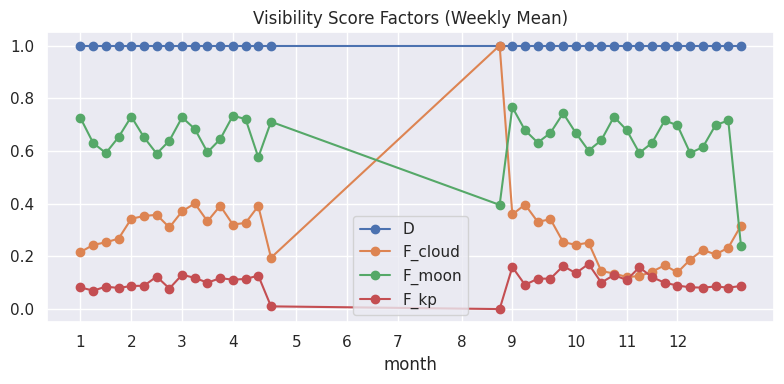

In [10]:
# Weekly mean of visibility-score factors (D, F_cloud, F_moon, F_kp)
factor_cols = ['D', 'F_cloud', 'F_moon', 'F_kp']
missing = [c for c in factor_cols if c not in yellowknife.columns]
if missing:
    raise KeyError(f'Missing columns in yellowknife: {missing}')

yellowknife['week'] = yellowknife['timestamp_utc'].dt.isocalendar().week.astype(int)
weekly_factors = (
    yellowknife[yellowknife['is_night'] == True]
    .groupby('week')[factor_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
for col in factor_cols:
    plt.plot(weekly_factors['week'], weekly_factors[col], marker='o', label=col)
plt.title('Visibility Score Factors (Weekly Mean)')
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel('month')
plt.tight_layout()
plt.legend()
plt.show()


## Extra 1) Week-of-year climatology (sum of nightly scores)

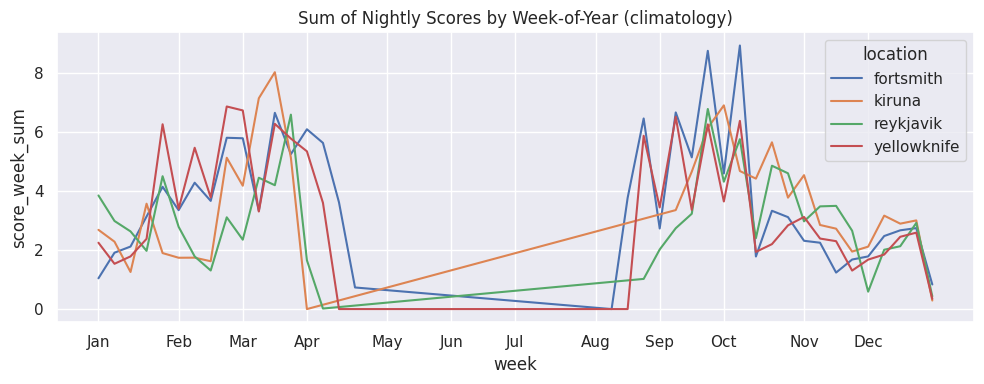

In [11]:
weekofyear = nightly_all.copy()
weekofyear["week"] = weekofyear["night_date_local"].dt.isocalendar().week.astype(int)
weekofyear_clim = weekofyear.groupby(["location", "week"]).agg(
    score_week_sum=("S_night_mean", "sum")
).reset_index()

# map weeks to month labels (ticks at first week of each month)
ref = pd.date_range("2001-01-01", "2001-12-31", freq="W-MON")
ref_weeks = ref.isocalendar().week.astype(int)
ref_months = ref.month
month_tick = pd.DataFrame({"week": ref_weeks, "month": ref_months}).drop_duplicates("month")
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 4))
sns.lineplot(data=weekofyear_clim, x="week", y="score_week_sum", hue="location")
plt.title("Sum of Nightly Scores by Week-of-Year (climatology)")
plt.xticks(month_tick["week"], month_labels)
plt.tight_layout()
plt.show()


## Extra 3) Total opportunity = S_night_mean * night_duration_hours

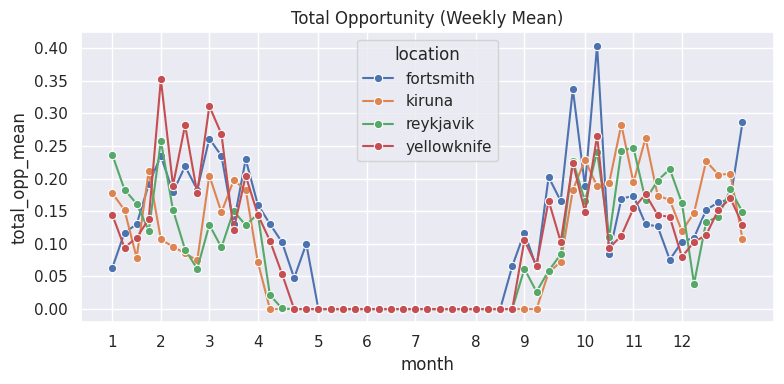

In [12]:
nightly_all["total_opportunity"] = nightly_all["S_night_mean"] *nightly_all["night_duration_hours"]

weekly = nightly_all.copy()
weekly["week"] = weekly["night_date_local"].dt.isocalendar().week.astype(int)

tot_weekly = weekly.groupby(["location", "week"]).agg(
  total_opp_mean=("total_opportunity", "mean")
).reset_index()

# fill missing weeks with 0
all_weeks = range(1, 54)
locations = tot_weekly["location"].unique()
full_index = pd.MultiIndex.from_product([locations, all_weeks],
names=["location", "week"])
tot_weekly_full = tot_weekly.set_index(["location",
"week"]).reindex(full_index).reset_index()
tot_weekly_full["total_opp_mean"] =tot_weekly_full["total_opp_mean"].fillna(0)

plt.figure(figsize=(8, 4))
sns.lineplot(data=tot_weekly_full, x="week", y="total_opp_mean",
hue="location", marker="o")
plt.title("Total Opportunity (Weekly Mean)")
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.tight_layout()
plt.show()



## Conclusion

The visibility score exhibits **physically consistent seasonal behavior** across all locations, validating the formulation defined in `target_7b_score.txt`.

* **Strong winter maxima, summer collapse**
  Total opportunity and weekly score climatologies peak during local winter (≈ Sep–Mar) and collapse to near-zero in late spring–summer, driven by the absence of astronomical night. This confirms that the **darkness factor (D)** correctly dominates seasonal availability.

* **Secondary modulation by clouds and moon**
  Within the dark season, variability is primarily controlled by **cloud cover** and **moon illumination**, which introduce week-to-week fluctuations around the winter plateau. These effects are visible as smooth modulations rather than regime shifts, consistent with meteorological and lunar drivers.

* **Kp acts as an event-scale enhancer, not a seasonal driver**
  The **Kp factor** remains low on average and does not exhibit a strong seasonal cycle, indicating that geomagnetic activity modulates visibility opportunistically rather than defining seasonal structure.

* **Geographical differences are coherent**
  High-latitude continental sites (e.g., Yellowknife, Fort Smith) show higher winter opportunity than Reykjavik and Kiruna, consistent with differences in latitude, climatology, and cloud regimes.

Overall, the score behaves as intended:
**astronomical darkness sets the envelope**, while **clouds, moon, and Kp shape short-term variability inside that envelope**.
This validates the scoring framework as a physically plausible baseline for downstream site ranking, forecasting, and model evaluation.
